In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

n = 250   # ~250 trading days, about a year
dates = pd.date_range('2024-01-01', periods=n, freq='B')  # business days
returns = np.random.normal(loc=0.0003, scale=0.01, size=n)  # daily returns
price = 100 * (1 + returns).cumprod()

df = pd.DataFrame({'date': dates, 'price': price})
df['ret'] = df['price'].pct_change()
df = df.set_index('date')

os.makedirs('data/raw', exist_ok=True)
df.to_csv('data/raw/synthetic_prices.csv')
df.head()

,price,ret
date,,
2024-01-01,100.526714,NaN
2024-01-02,100.417880,-0.001083
2024-01-03,101.098400,0.006777
2024-01-04,102.668488,0.015530
2024-01-05,102.458887,-0.002042


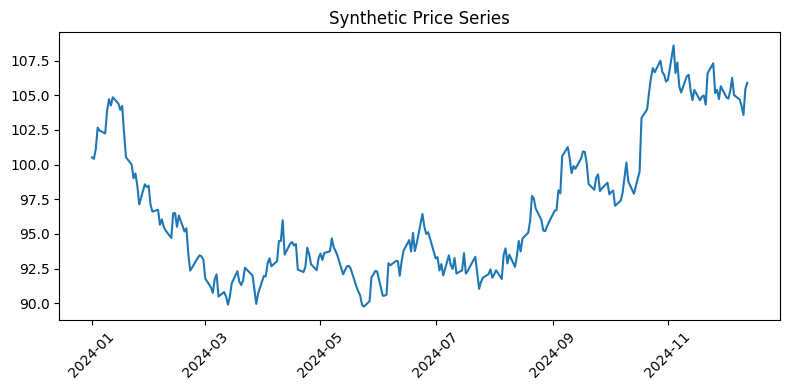

In [2]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df['price'])
plt.title('Synthetic Price Series')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
df['lag_1'] = df['ret'].shift(1)
df['rolling_mean_5'] = df['ret'].rolling(5).mean()
df['rolling_std_5'] = df['ret'].rolling(5).std()
df['momentum_5'] = df['price'] / df['price'].shift(5) - 1

df[['ret', 'lag_1', 'rolling_mean_5', 'rolling_std_5', 'momentum_5']].head(10)

,ret,lag_1,rolling_mean_5,rolling_std_5,momentum_5
date,,,,,
2024-01-01,NaN,NaN,NaN,NaN,NaN
2024-01-02,-0.001083,NaN,NaN,NaN,NaN
2024-01-03,0.006777,-0.001083,NaN,NaN,NaN
2024-01-04,0.015530,0.006777,NaN,NaN,NaN
2024-01-05,-0.002042,0.015530,NaN,NaN,NaN
2024-01-08,-0.002041,-0.002042,0.003428,0.007711,0.017140
2024-01-09,0.016092,-0.002041,0.006863,0.008929,0.034628
2024-01-10,0.007974,0.016092,0.007103,0.008942,0.035859
2024-01-11,-0.004395,0.007974,0.003118,0.008683,0.015535


In [4]:
df['y_up'] = (df['ret'].shift(-1) > 0).astype(int)
df = df.dropna()   # drop rows with NaN features or NaN target (the last row has no "next day")
df[['ret', 'y_up']].head()

,ret,y_up
date,,
2024-01-08,-0.002041,1
2024-01-09,0.016092,1
2024-01-10,0.007974,0
2024-01-11,-0.004395,1
2024-01-12,0.005726,0


In [5]:
feature_cols = ['lag_1', 'rolling_mean_5', 'rolling_std_5', 'momentum_5']
X = df[feature_cols]
y = df['y_up']

split_idx = int(len(df) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (183, 4) Test: (62, 4)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.645
Precision: 0.676
Recall: 0.714
F1: 0.694

Confusion Matrix:
 [[15 12]
 [10 25]]


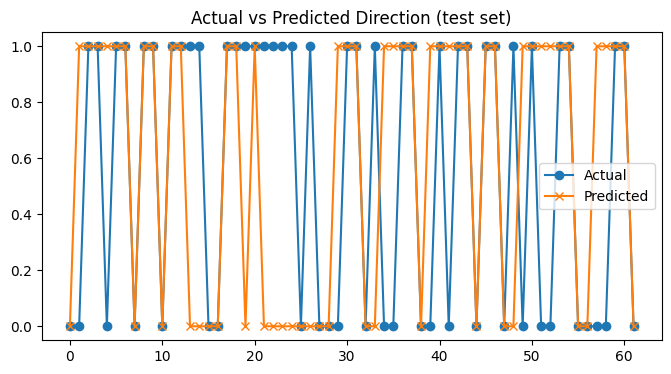

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Direction (test set)')
plt.legend()
plt.show()